In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

In [2]:
# -----------------------------
# 1. Synthetic Data Generation
# -----------------------------
np.random.seed(42)
n_samples = 1200


# Features: amino acid composition proxies (simplified)
amino_acid_hydrophobicity = np.random.uniform(-1, 1, n_samples)
molecular_weight = np.random.uniform(10, 200, n_samples)
iso_point = np.random.uniform(4, 10, n_samples)
charge = np.random.uniform(-5, 5, n_samples)
aromaticity = np.random.uniform(0, 1, n_samples)
secondary_struct = np.random.uniform(0, 1, n_samples)


# Label generation rule: more hydrophobic, heavier proteins less soluble
solubility_score = (0.6 * (-amino_acid_hydrophobicity) +
0.3 * (1 / molecular_weight) +
0.2 * (-(abs(iso_point - 7))) +
np.random.normal(0, 0.1, n_samples))


labels = (solubility_score > np.median(solubility_score)).astype(int) # 1 = Soluble, 0 = Insoluble

In [3]:
# Create DataFrame
data = pd.DataFrame({
'Hydrophobicity': amino_acid_hydrophobicity,
'MolecularWeight': molecular_weight,
'IsoelectricPoint': iso_point,
'Charge': charge,
'Aromaticity': aromaticity,
'SecondaryStruct': secondary_struct,
'Soluble': labels
})

In [5]:
# Save dataset
data.to_csv("/content/synthetic_protein_dataset.csv", index=False)

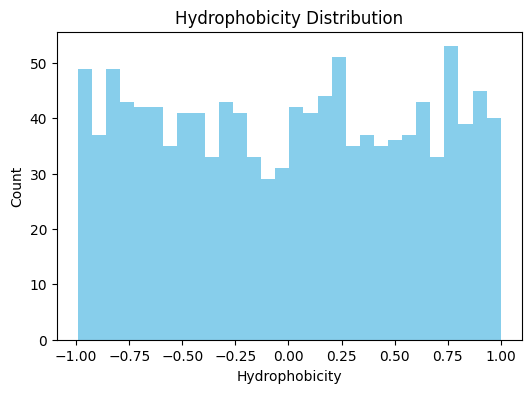

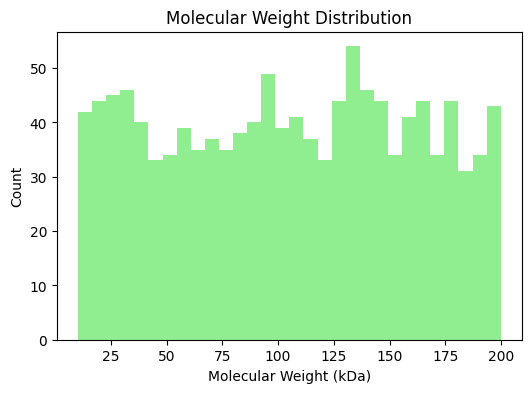

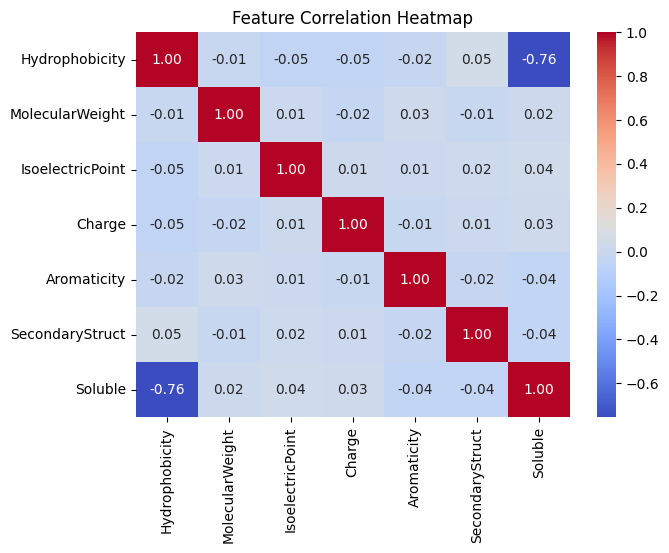

In [6]:
# -----------------------------
# 2. Exploratory Data Analysis
# -----------------------------
plt.figure(figsize=(6, 4))
plt.hist(data['Hydrophobicity'], bins=30, color='skyblue')
plt.title("Hydrophobicity Distribution")
plt.xlabel("Hydrophobicity")
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(6, 4))
plt.hist(data['MolecularWeight'], bins=30, color='lightgreen')
plt.title("Molecular Weight Distribution")
plt.xlabel("Molecular Weight (kDa)")
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(7, 5))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
# -----------------------------
# 3. Preprocessing
# -----------------------------
X = data.drop('Soluble', axis=1)
y = data['Soluble']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# -----------------------------
# 4. Model Development
# -----------------------------
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)


tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)


forest = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, random_state=42)

In [10]:
# -----------------------------
# 5. Evaluation
# -----------------------------
models = {'Logistic Regression': log_reg, 'Decision Tree': tree, 'Random Forest': forest}

performance_summary = []

for name, model in models.items():
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    performance_summary.append([name, acc, prec, rec, f1, auc])

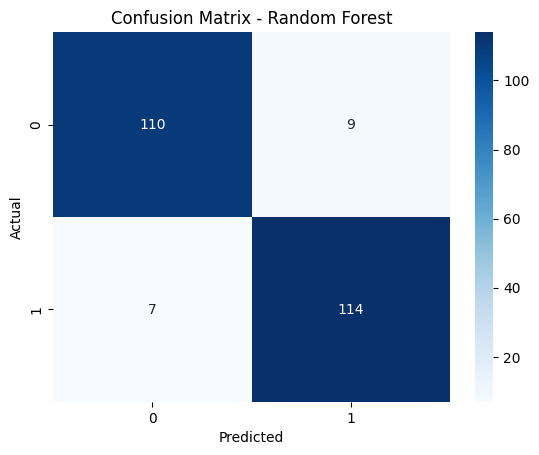

In [11]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

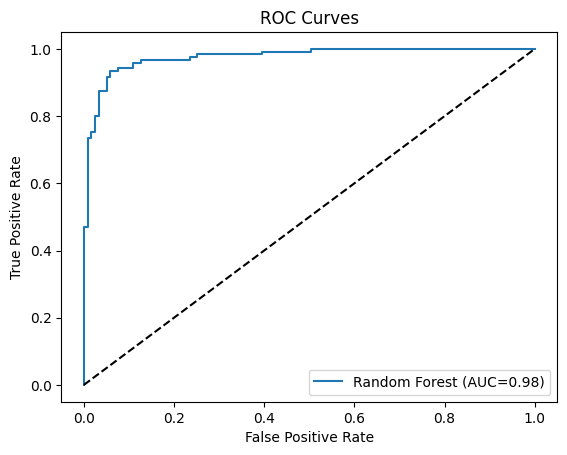

In [13]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")


plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


perf_df = pd.DataFrame(performance_summary, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"])
perf_df.to_csv("/content/model_performance_summary.csv", index=False)

In [15]:
# -----------------------------
# 6. Feature Importance
# -----------------------------
log_reg_importances = log_reg.coef_[0]
forest_importances = forest.feature_importances_
tree_importances = tree.feature_importances_


importance_df = pd.DataFrame({
'Feature': X.columns,
'Logistic_Coeff': log_reg_importances,
'DecisionTree_Importance': tree_importances,
'RandomForest_Importance': forest_importances
})
importance_df.to_csv("/content/feature_importances.csv", index=False)


print("Model Performance Summary:\n", perf_df)
print("\nFeature Importances:\n", importance_df)

Model Performance Summary:
                  Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression  0.862500   0.879310  0.842975  0.860759  0.943468
1        Decision Tree  0.879167   0.889831  0.867769  0.878661  0.923432
2        Random Forest  0.933333   0.926829  0.942149  0.934426  0.975762

Feature Importances:
             Feature  Logistic_Coeff  DecisionTree_Importance  \
0    Hydrophobicity       -2.715005                 0.732341   
1   MolecularWeight       -0.001381                 0.004175   
2  IsoelectricPoint       -0.065597                 0.245304   
3            Charge       -0.043555                 0.000000   
4       Aromaticity       -0.290846                 0.018179   
5   SecondaryStruct       -0.028323                 0.000000   

   RandomForest_Importance  
0                 0.714694  
1                 0.028537  
2                 0.155352  
3                 0.033315  
4                 0.033367  
5                 0.034734  


In [16]:
# -----------------------------
# 7. Sample Predictions
# -----------------------------
sample_X = X_test[:10]
sample_y = y_test[:10]
sample_pred = forest.predict(sample_X)
sample_prob = forest.predict_proba(sample_X)[:, 1]


sample_results = pd.DataFrame(sample_X)
sample_results['Actual'] = sample_y.values
sample_results['Predicted'] = sample_pred
sample_results['Pred_Prob'] = sample_prob
print("\nSample Predictions:\n", sample_results)


Sample Predictions:
       Hydrophobicity  MolecularWeight  IsoelectricPoint    Charge  \
1178        0.522056        94.819708          8.449849 -2.588348   
865         0.119281       159.392858          4.414275 -1.039990   
101         0.272821       187.880327          8.587167  1.785000   
439        -0.837302       186.130184          6.230344  0.778071   
58         -0.909545        22.199698          6.933387  1.151291   
1120        0.777496       182.446090          5.376195 -1.549832   
323        -0.440132        29.269957          6.747975 -2.340715   
974        -0.937634        53.164116          8.889638  2.600055   
411         0.900124       133.666700          7.843691 -1.080894   
855        -0.618625       137.114244          4.857052 -4.403827   

      Aromaticity  SecondaryStruct  Actual  Predicted  Pred_Prob  
1178     0.537581         0.210528       0          0   0.178145  
865      0.781462         0.303364       0          0   0.128017  
101      0.483860